In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import os

In [52]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [4]:
from pathlib import Path

proyecto = Path.cwd().parent
print("Carpeta del proyecto:", proyecto)

print("\nContenido de la carpeta del proyecto:")
for p in proyecto.iterdir():
    print(p.name)

Carpeta del proyecto: c:\Users\User\Desktop\Proyecto_IA

Contenido de la carpeta del proyecto:
agente
api
dataset
documentos
logs
modelo
notebooks
requerimientos.txt


In [5]:
DATASET_PATH = Path(r"c:\Users\User\Desktop\Proyecto_IA\dataset\accepted_2007_to_2018Q4.csv")

print("Ruta:", DATASET_PATH)
print("activo:", DATASET_PATH.exists())

df = pd.read_csv(DATASET_PATH, low_memory=False, nrows=5)
display(df)

Ruta: c:\Users\User\Desktop\Proyecto_IA\dataset\accepted_2007_to_2018Q4.csv
activo: True


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df = pd.read_csv(DATASET_PATH, low_memory=False)
print(df.shape)

(2260701, 151)


In [7]:

print("Filas y columnas:")
print(df.shape)

print("\n" + "="*60)


df.info()

Filas y columnas:
(2260701, 151)

<class 'pandas.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), str(38)
memory usage: 2.5 GB


In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,2260701,2260701,68407277,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
member_id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,2260668.0,NaN,NaN,NaN,15046.931228,9190.245488,500.0,8000.0,12900.0,20000.0,40000.0
funded_amnt,2260668.0,NaN,NaN,NaN,15041.664057,9188.413022,500.0,8000.0,12875.0,20000.0,40000.0
funded_amnt_inv,2260668.0,NaN,NaN,NaN,15023.437745,9192.331679,0.0,8000.0,12800.0,20000.0,40000.0
...,...,...,...,...,...,...,...,...,...,...,...
settlement_status,34246,3,ACTIVE,14704,NaN,NaN,NaN,NaN,NaN,NaN,NaN
settlement_date,34246,90,Jan-2019,1710,NaN,NaN,NaN,NaN,NaN,NaN,NaN
settlement_amount,34246.0,NaN,NaN,NaN,5010.664267,3693.12259,44.21,2208.0,4146.11,6850.1725,33601.0
settlement_percentage,34246.0,NaN,NaN,NaN,47.780365,7.311822,0.2,45.0,45.0,50.0,521.35


In [9]:
loan_status = df["loan_status"].value_counts()

print(loan_status)

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64


In [10]:
loan_status_pct = (
    df["loan_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

loan_status_pct

loan_status
Fully Paid                                             47.63
Current                                                38.85
Charged Off                                            11.88
Late (31-120 days)                                      0.95
In Grace Period                                         0.37
Late (16-30 days)                                       0.19
Does not meet the credit policy. Status:Fully Paid      0.09
Does not meet the credit policy. Status:Charged Off     0.03
Default                                                 0.00
Name: proportion, dtype: float64

In [11]:
grupo_prestamo = [
    "loan_amnt",
    "funded_amnt",
    "funded_amnt_inv",
    "term",
    "int_rate",
    "installment",
    "grade",
    "sub_grade",
    "purpose"
]

df[grupo_prestamo].head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,purpose
0,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,debt_consolidation
1,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,small_business
2,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,home_improvement
3,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,debt_consolidation
4,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,major_purchase


In [12]:
df[grupo_prestamo].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
loan_amnt,2260668.0,NaN,NaN,NaN,15046.931228,9190.245488,500.0,8000.0,12900.0,20000.0,40000.0
funded_amnt,2260668.0,NaN,NaN,NaN,15041.664057,9188.413022,500.0,8000.0,12875.0,20000.0,40000.0
funded_amnt_inv,2260668.0,NaN,NaN,NaN,15023.437745,9192.331679,0.0,8000.0,12800.0,20000.0,40000.0
term,2260668,2,36 months,1609754,NaN,NaN,NaN,NaN,NaN,NaN,NaN
int_rate,2260668.0,NaN,NaN,NaN,13.092829,4.832138,5.31,9.49,12.62,15.99,30.99
installment,2260668.0,NaN,NaN,NaN,445.806823,267.173535,4.93,251.65,377.99,593.32,1719.83
grade,2260668,7,B,663557,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sub_grade,2260668,35,C1,145903,NaN,NaN,NaN,NaN,NaN,NaN,NaN
purpose,2260668,14,debt_consolidation,1277877,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
valores_nulos = (
    df.isnull()
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

valores_nulos.head(40)

member_id                                     100.00
orig_projected_additional_accrued_interest     99.62
hardship_reason                                99.52
hardship_payoff_balance_amount                 99.52
hardship_last_payment_amount                   99.52
payment_plan_start_date                        99.52
hardship_type                                  99.52
hardship_status                                99.52
hardship_start_date                            99.52
deferral_term                                  99.52
hardship_amount                                99.52
hardship_dpd                                   99.52
hardship_loan_status                           99.52
hardship_length                                99.52
hardship_end_date                              99.52
settlement_status                              98.49
debt_settlement_flag_date                      98.49
settlement_term                                98.49
settlement_percentage                         

In [14]:
variables_importantes = [
    "loan_amnt",
    "term",
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "purpose",
    "dti",
    "fico_range_low",
    "fico_range_high",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "total_acc",
    "pub_rec_bankruptcies"
]

df[variables_importantes].isnull().sum().sort_values(ascending=False)

emp_length              146940
dti                       1744
pub_rec_bankruptcies      1398
inq_last_6mths              63
delinq_2yrs                 62
total_acc                   62
open_acc                    62
annual_inc                  37
purpose                     33
home_ownership              33
term                        33
loan_amnt                   33
verification_status         33
fico_range_high             33
fico_range_low              33
dtype: int64

In [15]:
columnas_candidatas = [

    "loan_amnt",
    "term",
    "purpose",
    "annual_inc",
    "verification_status",
    "emp_length",
    "home_ownership",
    "dti",
    "fico_range_low",
    "fico_range_high",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "total_acc",
    "pub_rec",
    "pub_rec_bankruptcies",
    "mort_acc",
    "revol_bal",
    "revol_util",
    "collections_12_mths_ex_med",
    "acc_now_delinq",
    "tax_liens",
    "tot_coll_amt",
    "tot_cur_bal",
    "num_sats",
    
    "loan_status"
]

len(columnas_candidatas)

26

In [16]:
df_reducido = df[columnas_candidatas].copy()

print("Dimensiones del DataFrame original:")
print(df.shape)
print("Dimensiones del DataFrame reducido:")
print(df_reducido.shape)

Dimensiones del DataFrame original:
(2260701, 151)
Dimensiones del DataFrame reducido:
(2260701, 26)


In [17]:
df_reducido.info()

<class 'pandas.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Data columns (total 26 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   loan_amnt                   float64
 1   term                        str    
 2   purpose                     str    
 3   annual_inc                  float64
 4   verification_status         str    
 5   emp_length                  str    
 6   home_ownership              str    
 7   dti                         float64
 8   fico_range_low              float64
 9   fico_range_high             float64
 10  delinq_2yrs                 float64
 11  inq_last_6mths              float64
 12  open_acc                    float64
 13  total_acc                   float64
 14  pub_rec                     float64
 15  pub_rec_bankruptcies        float64
 16  mort_acc                    float64
 17  revol_bal                   float64
 18  revol_util                  float64
 19  collections_12_mths_ex_med  floa

In [18]:
df_reducido.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_amnt,2260668.0,15046.931228,9190.245488,500.0,8000.00,12900.00,20000.00,40000.0
annual_inc,2260664.0,77992.428687,112696.199574,0.0,46000.00,65000.00,93000.00,110000000.0
dti,2258957.0,18.824196,14.183329,-1.0,11.89,17.84,24.49,999.0
fico_range_low,2260668.0,698.588205,33.010376,610.0,675.00,690.00,715.00,845.0
fico_range_high,2260668.0,702.588400,33.011245,614.0,679.00,694.00,719.00,850.0
delinq_2yrs,2260639.0,0.306879,0.867230,0.0,0.00,0.00,0.00,58.0
inq_last_6mths,2260638.0,0.576835,0.885963,0.0,0.00,0.00,1.00,33.0
open_acc,2260639.0,11.612402,5.640861,0.0,8.00,11.00,14.00,101.0
total_acc,2260639.0,24.162552,11.987528,1.0,15.00,22.00,31.00,176.0
pub_rec,2260639.0,0.197528,0.570515,0.0,0.00,0.00,0.00,86.0


In [19]:
nulos = (
    df_reducido
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

nulos

emp_length                    146940
tot_coll_amt                   70309
tot_cur_bal                    70309
num_sats                       58623
mort_acc                       50063
revol_util                      1835
dti                             1744
pub_rec_bankruptcies            1398
collections_12_mths_ex_med       178
tax_liens                        138
inq_last_6mths                    63
delinq_2yrs                       62
open_acc                          62
total_acc                         62
acc_now_delinq                    62
pub_rec                           62
annual_inc                        37
loan_amnt                         33
fico_range_high                   33
fico_range_low                    33
home_ownership                    33
verification_status               33
purpose                           33
term                              33
revol_bal                         33
loan_status                       33
dtype: int64

In [20]:
df_reducido["loan_status"].value_counts()

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

In [21]:
porcentaje_nulos = (
    df_reducido
    .isnull()
    .mean() * 100
).sort_values(ascending=False)

porcentaje_nulos

emp_length                    6.499754
tot_coll_amt                  3.110053
tot_cur_bal                   3.110053
num_sats                      2.593134
mort_acc                      2.214490
revol_util                    0.081170
dti                           0.077144
pub_rec_bankruptcies          0.061839
collections_12_mths_ex_med    0.007874
tax_liens                     0.006104
inq_last_6mths                0.002787
delinq_2yrs                   0.002743
open_acc                      0.002743
total_acc                     0.002743
acc_now_delinq                0.002743
pub_rec                       0.002743
annual_inc                    0.001637
loan_amnt                     0.001460
fico_range_high               0.001460
fico_range_low                0.001460
home_ownership                0.001460
verification_status           0.001460
purpose                       0.001460
term                          0.001460
revol_bal                     0.001460
loan_status              

In [22]:
nivel_riesgo = {
    "Fully Paid": 0,
    "Late (16-30 days)": 1,
    "Late (31-120 days)": 1,
    "In Grace Period": 1,
    "Charged Off": 2
}

In [23]:
df_reducido["risk_level"] = df_reducido["loan_status"].map(nivel_riesgo)

df_reducido[["loan_status", "risk_level"]].head()

,loan_status,risk_level
0,Fully Paid,0.0
1,Fully Paid,0.0
2,Fully Paid,0.0
3,Current,NaN
4,Fully Paid,0.0


In [24]:
df_reducido[
    ["loan_status", "risk_level"]
].drop_duplicates().sort_values(
    by="risk_level",
    na_position="last"
)

,loan_status,risk_level
0,Fully Paid,0.0
66,In Grace Period,1.0
227,Late (31-120 days),1.0
1250,Late (16-30 days),1.0
13,Charged Off,2.0
3,Current,NaN
33636,Default,NaN
421095,NaN,NaN
1651666,Does not meet the credit policy. Status:Fully ...,NaN
1651667,Does not meet the credit policy. Status:Charge...,NaN


In [25]:
df_modelo = df_reducido.dropna(
    subset=["risk_level"]
).copy()

print("Registros antes del filtro:", len(df_reducido))
print("Registros después del filtro:", len(df_modelo))

Registros antes del filtro: 2260701
Registros después del filtro: 1379562


In [26]:
df_modelo["risk_level"] = df_modelo["risk_level"].astype(int)

df_modelo["risk_level"].dtype

dtype('int64')

In [27]:
conteo_riesgo = (
    df_modelo["risk_level"]
    .value_counts()
    .sort_index()
)

porcentaje_riesgo = (
    df_modelo["risk_level"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

distribucion_riesgo = pd.DataFrame({
    "cantidad": conteo_riesgo,
    "porcentaje": porcentaje_riesgo.round(2)
})

distribucion_riesgo.index = [
    "Riesgo bajo",
    "Riesgo medio",
    "Riesgo alto"
]

distribucion_riesgo

,cantidad,porcentaje
Riesgo bajo,1076751,78.05
Riesgo medio,34252,2.48
Riesgo alto,268559,19.47


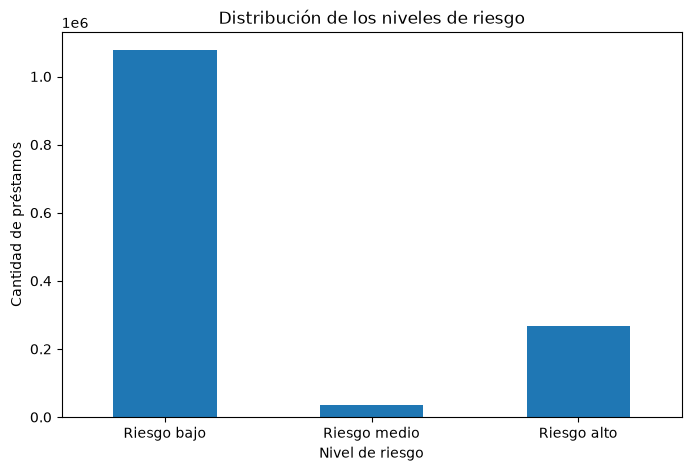

In [28]:
distribucion_riesgo["cantidad"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Distribución de los niveles de riesgo")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Cantidad de préstamos")
plt.xticks(rotation=0)
plt.show()

In [29]:
X = df_modelo.drop(columns=["loan_status", "risk_level"])

y = df_modelo["risk_level"]

In [30]:
X.dtypes

loan_amnt                     float64
term                              str
purpose                           str
annual_inc                    float64
verification_status               str
emp_length                        str
home_ownership                    str
dti                           float64
fico_range_low                float64
fico_range_high               float64
delinq_2yrs                   float64
inq_last_6mths                float64
open_acc                      float64
total_acc                     float64
pub_rec                       float64
pub_rec_bankruptcies          float64
mort_acc                      float64
revol_bal                     float64
revol_util                    float64
collections_12_mths_ex_med    float64
acc_now_delinq                float64
tax_liens                     float64
tot_coll_amt                  float64
tot_cur_bal                   float64
num_sats                      float64
dtype: object

In [31]:
variables_numericas = X.select_dtypes(
    include=["number"]
).columns.tolist()

variables_categoricas = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

In [32]:
print("Variables numéricas:", len(variables_numericas))

print("Variables categóricas:", len(variables_categoricas))


Variables numéricas: 20
Variables categóricas: 5


In [33]:
pipeline_num = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])

In [34]:
pipeline_categorico = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(handle_unknown="ignore")
    )
])

In [35]:
preprocesador = ColumnTransformer(
    transformers=[
        (
            "num",
            pipeline_num,
            variables_numericas
        ),
        (
            "cat",
            pipeline_categorico,
            variables_categoricas
        )
    ]
)

In [36]:
X_transformado = preprocesador.fit_transform(X)

In [37]:
print(X_transformado.shape)

(1379562, 56)


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [39]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1103649, 25)
X_test : (275913, 25)
y_train: (1103649,)
y_test : (275913,)


In [40]:
arbol_decision = DecisionTreeClassifier(
    max_depth=12,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)

In [41]:
modelo_inicial = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", arbol_decision)
])

In [42]:
modelo_inicial.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](25,)","['loan_amnt','term','purpose',...,'tot_coll_amt','tot_cur_bal','num_sats']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,25
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthroug

In [43]:
y_pred = modelo_inicial.predict(X_test)

In [44]:
print(y_pred[:20])

[1 2 0 0 0 2 2 0 0 0 0 0 2 0 0 0 1 2 0 2]


In [45]:
comparacion = pd.DataFrame({
    "valor_real": y_test.iloc[:20].values,
    "prediccion": y_pred[:20]
})

comparacion

,valor_real,prediccion
0,2,1
1,2,2
2,0,0
3,0,0
4,0,0
5,0,2
6,0,2
7,0,0
8,0,0
9,0,0


In [47]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))

Accuracy: 0.5175


In [48]:
balanced_accuracy = balanced_accuracy_score(y_test, y_pred)

print("Balanced accuracy:", round(balanced_accuracy, 4))

Balanced accuracy: 0.4505


In [49]:
nombres_clases = [
    "Riesgo bajo",
    "Riesgo medio",
    "Riesgo alto"
]

print(
    classification_report(
        y_test,
        y_pred,
        target_names=nombres_clases,
        digits=4
    )
)

              precision    recall  f1-score   support

 Riesgo bajo     0.8607    0.5457    0.6679    215351
Riesgo medio     0.0428    0.3842    0.0770      6850
 Riesgo alto     0.2910    0.4216    0.3443     53712

    accuracy                         0.5175    275913
   macro avg     0.3981    0.4505    0.3631    275913
weighted avg     0.7295    0.5175    0.5902    275913



In [50]:
matriz = confusion_matrix(y_test, y_pred)

matriz

array([[117515,  44851,  52985],
       [  2025,   2632,   2193],
       [ 16998,  14071,  22643]])

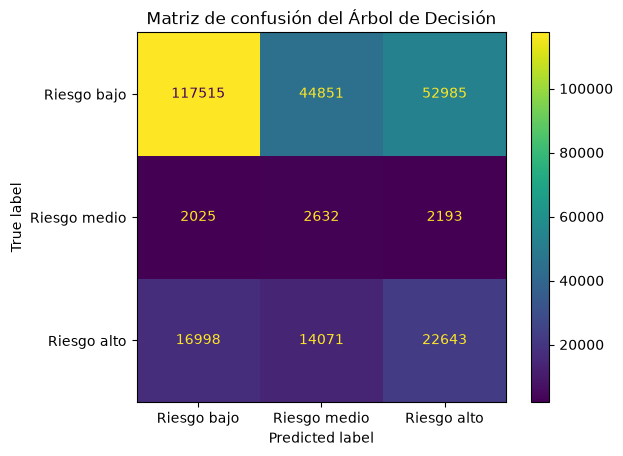

In [53]:
visualizacion = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=nombres_clases
)

visualizacion.plot(
    values_format="d",
    xticks_rotation=0
)

plt.title("Matriz de confusión del Árbol de Decisión")
plt.show()

In [55]:
importancias = modelo_inicial.named_steps["modelo"].feature_importances_

In [56]:
modelo = modelo_inicial.named_steps["modelo"]

In [58]:
importancias = modelo.feature_importances_

In [59]:
nombres_variables = modelo_inicial.named_steps[
    "preprocesamiento"
].get_feature_names_out()

In [60]:
tabla_importancias = pd.DataFrame({
    "Variable": nombres_variables,
    "Importancia": importancias
})

tabla_importancias = (
    tabla_importancias
    .sort_values(
        by="Importancia",
        ascending=False
    )
)

tabla_importancias.head(30)

,Variable,Importancia
20,cat__term_ 36 months,0.177753
2,num__dti,0.109696
0,num__loan_amnt,0.108909
18,num__tot_cur_bal,0.083607
4,num__fico_range_high,0.078929
11,num__mort_acc,0.071849
1,num__annual_inc,0.060227
8,num__total_acc,0.058796
13,num__revol_util,0.051443
12,num__revol_bal,0.048351


In [62]:
tabla_original = tabla_importancias.copy()

def obtener_variable_original(nombre):
   
    nombre = nombre.replace("num__", "").replace("cat__", "")

    
    if nombre.startswith("term_"):
        return "term"

    if nombre.startswith("purpose_"):
        return "purpose"

    if nombre.startswith("verification_status_"):
        return "verification_status"

    if nombre.startswith("emp_length_"):
        return "emp_length"

    if nombre.startswith("home_ownership_"):
        return "home_ownership"

   
    return nombre

tabla_original["Variable_original"] = tabla_original["Variable"].apply(
    obtener_variable_original
)

tabla_final = (
    tabla_original
    .groupby("Variable_original")["Importancia"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

tabla_final

,Variable_original,Importancia
0,term,0.177753
1,dti,0.109696
2,loan_amnt,0.108909
3,tot_cur_bal,0.083607
4,fico_range_high,0.078929
5,mort_acc,0.071849
6,annual_inc,0.060227
7,total_acc,0.058796
8,revol_util,0.051443
9,revol_bal,0.048351


In [63]:
variables_finales = [
    "loan_amnt",
    "term",
    "purpose",
    "annual_inc",
    "verification_status",
    "emp_length",
    "home_ownership",
    "dti",
    "fico_range_low",
    "inq_last_6mths",
    "total_acc",
    "mort_acc",
    "pub_rec",
    "delinq_2yrs",
    "pub_rec_bankruptcies"
]


In [64]:
X_final = df_modelo[variables_finales]

y_final = df_modelo["risk_level"]

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y_final,
    test_size=0.20,
    random_state=42,
    stratify=y_final
)

In [66]:
variables_numericas = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

variables_categoricas = X_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Numéricas:", variables_numericas)
print("Categóricas:", variables_categoricas)

Numéricas: ['loan_amnt', 'annual_inc', 'dti', 'fico_range_low', 'inq_last_6mths', 'total_acc', 'mort_acc', 'pub_rec', 'delinq_2yrs', 'pub_rec_bankruptcies']
Categóricas: ['term', 'purpose', 'verification_status', 'emp_length', 'home_ownership']


In [67]:
pipeline_numerico = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

pipeline_categorico = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocesador = ColumnTransformer([
    ("num", pipeline_numerico, variables_numericas),
    ("cat", pipeline_categorico, variables_categoricas)
])

In [90]:
arbol_final = DecisionTreeClassifier(
    max_depth=12,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)

In [91]:
modelo_final = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", arbol_final)
])

In [92]:
modelo_final.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['loan_amnt','term','purpose',...,'pub_rec','delinq_2yrs', 'pub_rec_bankruptcies']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [93]:
y_pred = modelo_final.predict(X_test)


In [94]:
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Balanced Accuracy:", round(balanced_accuracy_score(y_test, y_pred), 4))

Accuracy: 0.5209
Balanced Accuracy: 0.4492


In [95]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Riesgo bajo",
            "Riesgo medio",
            "Riesgo alto"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

 Riesgo bajo     0.8630    0.5402    0.6645    215351
Riesgo medio     0.0428    0.3410    0.0761      6850
 Riesgo alto     0.2892    0.4663    0.3570     53712

    accuracy                         0.5209    275913
   macro avg     0.3983    0.4492    0.3659    275913
weighted avg     0.7309    0.5209    0.5900    275913

